# 📋 Notebook 2 — Baseline Replication: Saeed (2025)

**Reference:**
> Saeed, E.M.H. (2025). *An Ensemble Voting Classifier based on Machine Learning Models for Phishing Detection.* IJSRSET, 12(1), 15–27. DOI: 10.32628/IJSRSET251211

## What the paper reports (per model):
1. **Confusion Matrix** — heatmap with raw TP/TN/FP/FN counts
2. **Classification Report** — precision, recall, f1-score, support for each class + accuracy + macro avg + weighted avg
3. **Table I** — accuracy comparison across all models

## Exact methodology reproduced:
- Dataset: UCI Phishing Websites (`UCI-2015.csv`), labels: 1=phishing, -1=legitimate
- Preprocessing: `StandardScaler` only — **no SMOTE**
- Split: **80% train / 20% test**, `random_state=42`, **no stratify**
  - Verified: reproduces paper's exact test set (class 0: 976, class 1: 1235, total: 2211)
- Models: Logistic Regression, Gradient Boosting, K-Nearest Neighbors (all sklearn defaults)
- Ensemble: Hard Voting (majority class label)
- No cross-validation, no hyperparameter tuning

## Dataset run:
- **UCI-2015** — exact Saeed (2025) conditions


In [1]:
# ==========================================
# 1. SETUP
# ==========================================
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'figure.dpi': 120})
SEED = 42
print('✅ Setup complete.')

✅ Setup complete.


In [2]:
# ==========================================
# 2. LOAD DATASET
# ==========================================

# --- UCI-2015 (UCI Phishing Websites) ---
# Original labels: 1=phishing, -1=legitimate
df_base = pd.read_csv('UCI-2015.csv')
df_base = df_base.drop(columns=['Index'], errors='ignore')
df_base['label'] = df_base['class'].map({1: 1, -1: 0})
df_base = df_base.drop(columns=['class'])

assert df_base['label'].isnull().sum() == 0, 'Unexpected nulls in label'
assert df_base.isnull().sum().sum() == 0,    'Unexpected nulls in features'

print('UCI-2015:')
print(f'  Rows: {len(df_base):,}')
print(f'  Class 0 (legitimate): {(df_base.label==0).sum():,}  |  '
      f'Class 1 (phishing): {(df_base.label==1).sum():,}')


UCI-2015:
  Rows: 11,054
  Class 0 (legitimate): 4,897  |  Class 1 (phishing): 6,157


In [3]:
# ==========================================
# 3. UTILITY FUNCTIONS
# ==========================================

def plot_confusion_matrix(y_true, y_pred, model_name, dataset_label, ax):
    """
    Plots a confusion matrix styled exactly as in Saeed (2025):
    - Raw counts annotated
    - True Labels on y-axis, Predicted Labels on x-axis
    - Class values 0 (legitimate) and 1 (phishing)
    """
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=[0, 1], yticklabels=[0, 1],
        linewidths=0.5, linecolor='white', cbar=True,
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    ax.set_xlabel('Predicted Labels', fontsize=11)
    ax.set_ylabel('True Labels', fontsize=11)
    ax.set_title(f'Confusion Matrix\n{model_name}\n({dataset_label})', fontweight='bold')


def print_classification_report(y_true, y_pred, model_name, dataset_label):
    """Prints sklearn classification report exactly as paper shows it."""
    print(f'\n--- {model_name} | {dataset_label} ---')
    print(classification_report(
        y_true, y_pred,
        target_names=['0 (legitimate)', '1 (phishing)'],
        digits=2
    ))


def get_metrics(y_true, y_pred, model_name):
    return {
        'Model':     model_name,
        'Accuracy':  round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0) * 100, 2),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0) * 100, 2),
        'F1':        round(f1_score(y_true, y_pred, zero_division=0) * 100, 2),
    }


print('✅ Utilities ready.')

✅ Utilities ready.


In [4]:
# ==========================================
# 4. SAEED (2025) PIPELINE FUNCTION
# ==========================================

def run_saeed_pipeline(df, dataset_label):
    """Faithful replication of Saeed (2025) pipeline."""
    print(f'\n{"="*60}')
    print(f'  {dataset_label}')
    print(f'{"="*60}')

    X = df.drop(columns=['label'])
    y = df['label']
    print(f'  Rows: {len(df):,}  |  '
          f'Legitimate (0): {(y==0).sum():,}  |  '
          f'Phishing (1): {(y==1).sum():,}')

    # Exact Saeed split: 80/20, no stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )
    print(f'  Train: {len(X_train):,}  |  Test: {len(X_test):,}')
    print(f'  Test class 0: {(y_test==0).sum():,}  |  Test class 1: {(y_test==1).sum():,}')

    # StandardScaler (their only preprocessing step)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Individual models — sklearn defaults as per paper
    base_models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
        'Gradient Boosting':   GradientBoostingClassifier(random_state=SEED),
        'KNN':                 KNeighborsClassifier(),
    }

    results   = []
    all_preds = {}
    trained   = {}

    for name, model in base_models.items():
        model.fit(X_train_s, y_train)
        pred          = model.predict(X_test_s)
        all_preds[name] = pred
        trained[name]   = model
        results.append(get_metrics(y_test, pred, name))

    # Hard Voting Ensemble
    ensemble = VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(max_iter=1000, random_state=SEED)),
            ('gb',  GradientBoostingClassifier(random_state=SEED)),
            ('knn', KNeighborsClassifier()),
        ],
        voting='hard'
    )
    ensemble.fit(X_train_s, y_train)
    ens_pred = ensemble.predict(X_test_s)
    all_preds['Hard Voting Ensemble'] = ens_pred
    results.append(get_metrics(y_test, ens_pred, 'Hard Voting Ensemble'))

    df_results = pd.DataFrame(results)
    df_results['Dataset'] = dataset_label

    return df_results, all_preds, y_test, trained


print('✅ Pipeline function ready.')


✅ Pipeline function ready.


In [5]:
# ==========================================
# 5. RUN — UCI-2015
# ==========================================

res, preds, yt, trained = run_saeed_pipeline(df_base, 'UCI-2015')



  UCI-2015
  Rows: 11,054  |  Legitimate (0): 4,897  |  Phishing (1): 6,157
  Train: 8,843  |  Test: 2,211
  Test class 0: 976  |  Test class 1: 1,235


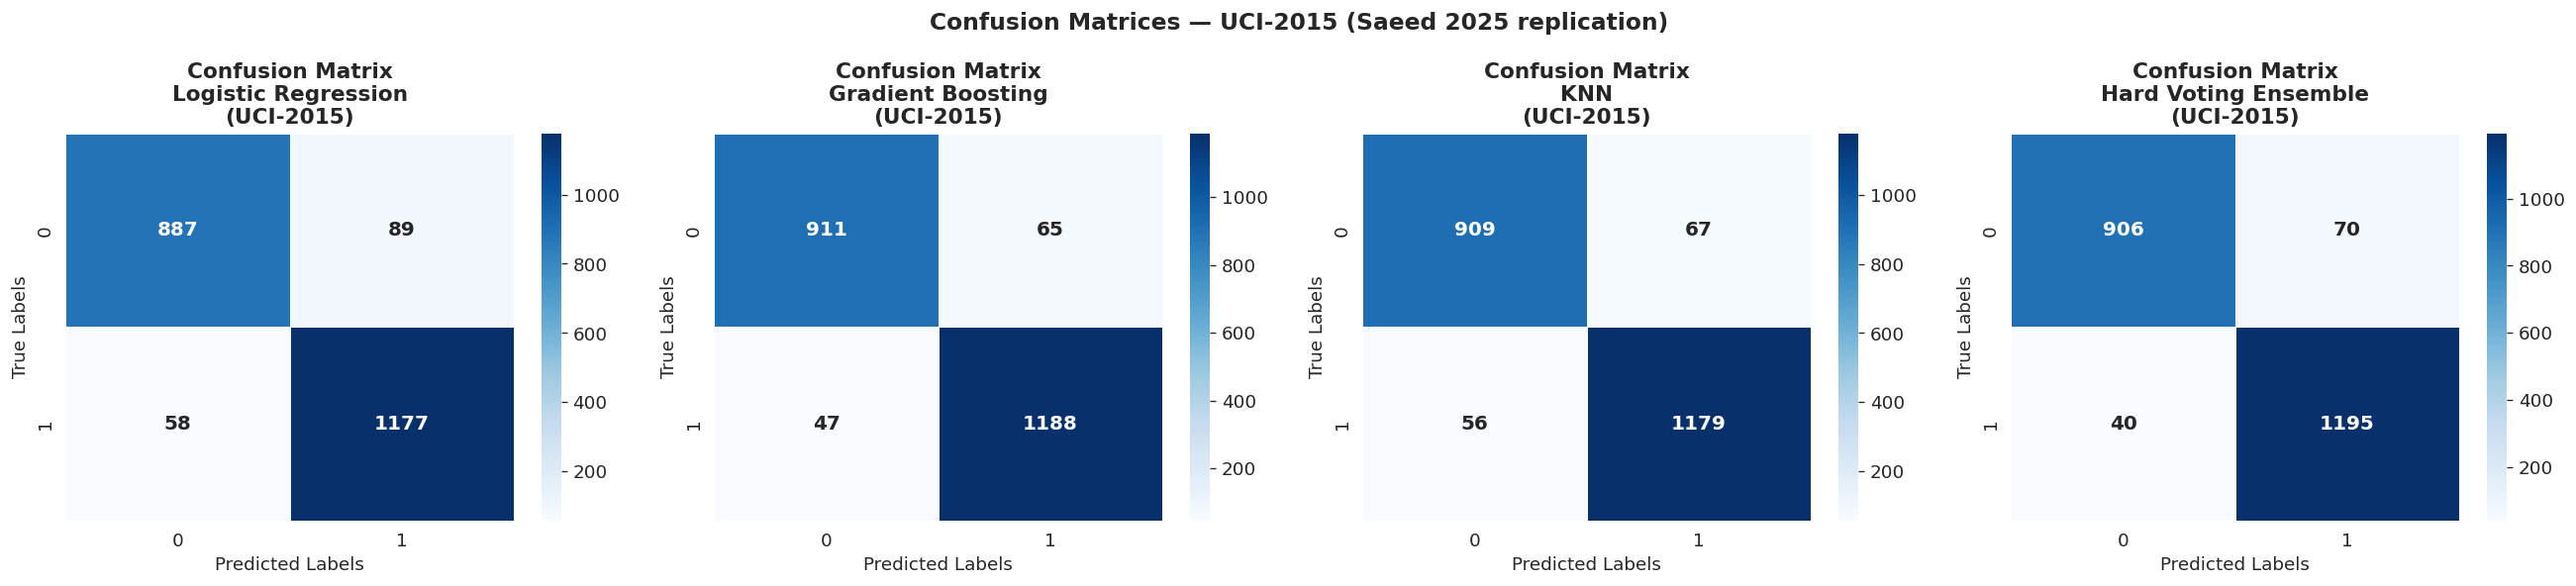

Saved: nb2_cm_uci2015.png


In [6]:
# ── Confusion Matrices — UCI-2015 ──

model_order = ['Logistic Regression', 'Gradient Boosting', 'KNN', 'Hard Voting Ensemble']
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, name in zip(axes, model_order):
    plot_confusion_matrix(yt, preds[name], name, 'UCI-2015', ax)

fig.suptitle('Confusion Matrices — UCI-2015 (Saeed 2025 replication)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb2_cm_uci2015.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb2_cm_uci2015.png')


In [7]:
# ── Classification Reports — UCI-2015 ──

for name in model_order:
    print_classification_report(yt, preds[name], name, 'UCI-2015')



--- Logistic Regression | UCI-2015 ---
                precision    recall  f1-score   support

0 (legitimate)       0.94      0.91      0.92       976
  1 (phishing)       0.93      0.95      0.94      1235

      accuracy                           0.93      2211
     macro avg       0.93      0.93      0.93      2211
  weighted avg       0.93      0.93      0.93      2211


--- Gradient Boosting | UCI-2015 ---
                precision    recall  f1-score   support

0 (legitimate)       0.95      0.93      0.94       976
  1 (phishing)       0.95      0.96      0.95      1235

      accuracy                           0.95      2211
     macro avg       0.95      0.95      0.95      2211
  weighted avg       0.95      0.95      0.95      2211


--- KNN | UCI-2015 ---
                precision    recall  f1-score   support

0 (legitimate)       0.94      0.93      0.94       976
  1 (phishing)       0.95      0.95      0.95      1235

      accuracy                           0.94     

In [8]:
# ── Accuracy Table — UCI-2015 (mirrors Table I of paper) ──

published = {
    'Logistic Regression':  93.31,
    'Gradient Boosting':    94.93,
    'KNN':                  94.35,
    'Hard Voting Ensemble': 95.02,
}

print('\nTable I (replicated) — UCI-2015:')
print(f'{"Model":<26} {"Replicated":>12} {"Published":>12} {"Match?":>8}')
print('-' * 62)
for _, row in res.iterrows():
    pub   = published.get(row['Model'], None)
    match = '✅' if pub and abs(row['Accuracy'] - pub) < 1.0 else '⚠️'
    pub_s = f'{pub:.2f}%' if pub else 'N/A'
    print(f'{row["Model"]:<26} {row["Accuracy"]:>10.2f}%  {pub_s:>10}  {match}')



Table I (replicated) — UCI-2015:
Model                        Replicated    Published   Match?
--------------------------------------------------------------
Logistic Regression             93.35%      93.31%  ✅
Gradient Boosting               94.93%      94.93%  ✅
KNN                             94.44%      94.35%  ✅
Hard Voting Ensemble            95.02%      95.02%  ✅


In [9]:
# ==========================================
# 6. FULL RESULTS TABLE
# ==========================================

print('\n📌 SAEED (2025) REPLICATION — UCI-2015 RESULTS')
print('='*72)
print(f'  {"Model":<26} {"Accuracy":>10} {"Precision":>11} {"Recall":>9} {"F1":>9}')
print('  ' + '-'*62)
for _, row in res.iterrows():
    marker = '  ◀ ENSEMBLE' if row['Model'] == 'Hard Voting Ensemble' else ''
    print(f'  {row["Model"]:<26} {row["Accuracy"]:>9.2f}%'
          f' {row["Precision"]:>10.2f}%'
          f' {row["Recall"]:>8.2f}%'
          f' {row["F1"]:>8.2f}%{marker}')



📌 SAEED (2025) REPLICATION — UCI-2015 RESULTS
  Model                        Accuracy   Precision    Recall        F1
  --------------------------------------------------------------
  Logistic Regression            93.35%      92.97%    95.30%    94.12%
  Gradient Boosting              94.93%      94.81%    96.19%    95.50%
  KNN                            94.44%      94.62%    95.47%    95.04%
  Hard Voting Ensemble           95.02%      94.47%    96.76%    95.60%  ◀ ENSEMBLE


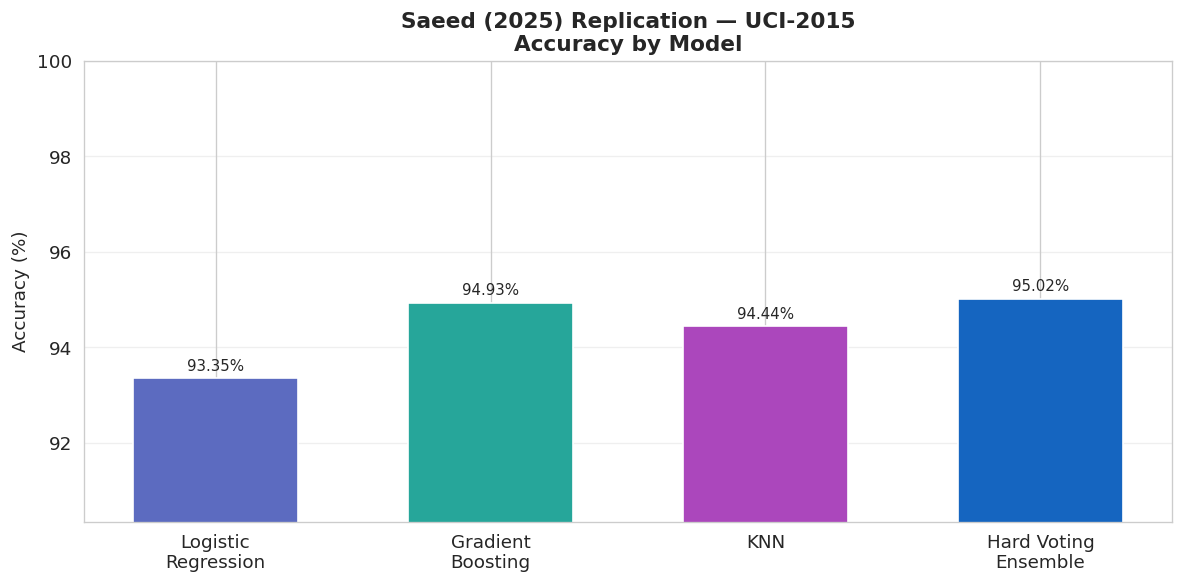

Saved: nb2_accuracy_chart.png


In [10]:
# ==========================================
# 7. ACCURACY BAR CHART
# ==========================================

x   = np.arange(len(model_order))
pal = ['#5C6BC0', '#26A69A', '#AB47BC', '#1565C0']
acc_vals = [res.set_index('Model').loc[m, 'Accuracy'] for m in model_order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, acc_vals, color=pal, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.2f%%', fontsize=9, padding=3)

ax.set_xticks(x)
ax.set_xticklabels(['Logistic\nRegression', 'Gradient\nBoosting',
                    'KNN', 'Hard Voting\nEnsemble'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Saeed (2025) Replication — UCI-2015\nAccuracy by Model',
             fontweight='bold')
ax.set_ylim(min(acc_vals) - 3, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nb2_accuracy_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nb2_accuracy_chart.png')


In [11]:
# ==========================================
# 8. EXPORT MODEL JSON  (browser extension)
# ==========================================
# Run this after training to regenerate extension/models/baseline_model_dsbase.json
import json

feature_names = df_base.drop(columns=['label']).columns.tolist()

# Use Gradient Boosting feature importances (engine.js baseline branch reads gb_feature_importances)
gb_model      = trained['Gradient Boosting']
gb_importances = {
    feat: round(float(imp), 6)
    for feat, imp in zip(feature_names, gb_model.feature_importances_)
}

ens_row = res.loc[res['Model'] == 'Hard Voting Ensemble'].iloc[0]

model_metrics_export = {
    row['Model']: {'acc': row['Accuracy'], 'prec': row['Precision'],
                   'rec': row['Recall'],   'f1':   row['F1']}
    for _, row in res.iterrows()
}

export = {
    'dataset':    'UCI-2015',
    'model_type': 'hard_vote_LR_GB_KNN',
    'feature_names': feature_names,
    'n_features': len(feature_names),
    'threshold':  0.5,
    'vote_type':  'hard',
    'voters':     ['Logistic Regression', 'Gradient Boosting', 'KNN'],
    'voter_weights': {
        'Logistic Regression': 0.333,
        'Gradient Boosting':   0.333,
        'KNN':                 0.333,
    },
    'gb_feature_importances': gb_importances,   # used by engine.js for scoring
    'ensemble_metrics': {
        'accuracy':  ens_row['Accuracy'],
        'f1':        ens_row['F1'],
        'precision': ens_row['Precision'],
        'recall':    ens_row['Recall'],
    },
    'model_metrics': model_metrics_export,
}

with open('baseline_model_dsbase.json', 'w') as f:
    json.dump(export, f, indent=2)

print('✅ Saved: baseline_model_dsbase.json')
print('   → Copy to extension/models/baseline_model_dsbase.json')
print(f'   Features : {len(feature_names)}')
print(f'   Ensemble accuracy: {ens_row["Accuracy"]:.2f}%')
print(f'\n   Top 5 GB importances:')
for feat, imp in sorted(gb_importances.items(), key=lambda x: -x[1])[:5]:
    print(f'     {feat:<35} {imp:.4f}')


✅ Saved: baseline_model_dsbase.json
   → Copy to extension/models/baseline_model_dsbase.json
   Features : 30
   Ensemble accuracy: 95.02%

   Top 5 GB importances:
     HTTPS                               0.7099
     AnchorURL                           0.1444
     PrefixSuffix-                       0.0375
     WebsiteTraffic                      0.0318
     LinksInScriptTags                   0.0286
